In [29]:
# 라이브러리 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 기본 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False # 숫자의 음수(-) 표시 정상 수행

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스 타입:", type(device))
print("사용 디바이스:", device)

사용 디바이스 타입: <class 'torch.device'>
사용 디바이스: cpu


In [30]:
# 전처리 데이터 준비

X_train_raw = pd.read_csv("data-files/X_train.csv").values.astype("float32") # values : dataframe -> numpy array
y_train_raw = pd.read_csv("data-files/y_train.csv").values.flatten().astype("float32") # flatten : n차원 배열 -> 1차원 배열
X_test_raw  = pd.read_csv("data-files/X_test.csv").values.astype("float32")
y_test_raw  = pd.read_csv("data-files/y_test.csv").values.flatten().astype("float32")

print(f"훈련 데이터: {X_train_raw.shape}")
print(f"테스트 데이터: {X_test_raw.shape}")
print(f"피처 수: {X_train_raw.shape[1]}")


훈련 데이터: (712, 9)
테스트 데이터: (179, 9)
피처 수: 9


In [31]:
# 데이터셋, 데이터로더 구성

class TitanicDataset(Dataset):
    def __init__(self, X, y): # __init__ : 자바의 생성자 함수, 객체 생성할 때 자동 호출
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):  # 전체 데이터 갯수 반환
        return len(self.X)

    def __getitem__(self, idx): # 특정 위치의 한 건의 데이터 반화 (X, y 각각 반환)
        return self.X[idx], self.y[idx]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.2, random_state=42, stratify=y_train_raw
)

BATCH_SIZE   = 32
train_loader = DataLoader(TitanicDataset(X_tr,       y_tr),       batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TitanicDataset(X_val,      y_val),      batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TitanicDataset(X_test_raw, y_test_raw), batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 {len(X_tr)}개 | 검증 {len(X_val)}개 | 테스트 {len(X_test_raw)}개")


훈련 569개 | 검증 143개 | 테스트 179개


In [32]:
# 모델 구조 설계

# class TitanicNet(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(32, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return self.net(x)

class TitanicNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

INPUT_DIM = X_tr.shape[1]
model     = TitanicNet(INPUT_DIM).to(device)
print(model)
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


TitanicNet(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
파라미터 수: 11,649


In [38]:
# 훈련 설계

EPOCHS = 80
LR     = 0.001

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

history      = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

patience, best_loss, no_improve = 10, float("inf"), 0  # 조기 학습 종료 위한 변수

for epoch in range(1, EPOCHS + 1):
    # 훈련
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device).unsqueeze(1)
        pred = model(X_b)
        loss = criterion(pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # 검증
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device).unsqueeze(1)
            pred      = model(X_b)
            val_loss += criterion(pred, y_b).item()
            correct  += ((pred >= 0.5).float() == y_b).sum().item()
            total    += y_b.size(0)
    val_loss /= len(val_loader)
    val_acc   = correct / total

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # 최고 성능 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "titanic_best.pt") # 모델 저장

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Val Acc: {val_acc:.2%}")


    val_loss_now = val_loss  # 실제 val_loss 값으로 대체

    if val_loss_now < best_loss:
        best_loss  = val_loss_now
        no_improve = 0
        torch.save(model.state_dict(), "early_stop_best.pt")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early Stopping at epoch {epoch}")
            break

print(f"\n최고 검증 정확도: {best_val_acc:.2%} → titanic_best.pt 저장")


Early Stopping at epoch 17

최고 검증 정확도: 81.82% → titanic_best.pt 저장


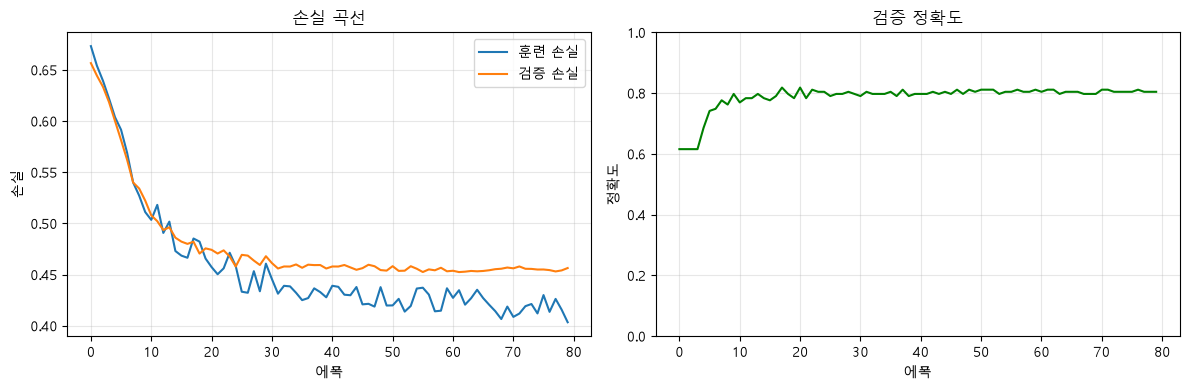

In [34]:
# 학습 과정 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="훈련 손실")
axes[0].plot(history["val_loss"],   label="검증 손실")
axes[0].set_title("손실 곡선")
axes[0].set_xlabel("에폭")
axes[0].set_ylabel("손실")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_acc"], color="green")
axes[1].set_title("검증 정확도")
axes[1].set_xlabel("에폭")
axes[1].set_ylabel("정확도")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=100, bbox_inches="tight")
plt.show()


In [35]:
# 최종 모델 테스트

# 최고 모델 불러오기
model.load_state_dict(torch.load("titanic_best.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        pred = model(X_b.to(device))
        all_preds.extend((pred >= 0.5).cpu().numpy().flatten().astype(int))  # 모델이 예측한 y값
        all_labels.extend(y_b.numpy().flatten().astype(int))                 # 실제 y값

print("=== 테스트 세트 평가 결과 ===")
print(classification_report(all_labels, all_preds,
                             target_names=["사망(0)", "생존(1)"]))


=== 테스트 세트 평가 결과 ===
              precision    recall  f1-score   support

       사망(0)       0.77      0.95      0.85       110
       생존(1)       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



In [36]:
confusion_matrix(all_labels, all_preds)

array([[104,   6],
       [ 31,  38]])

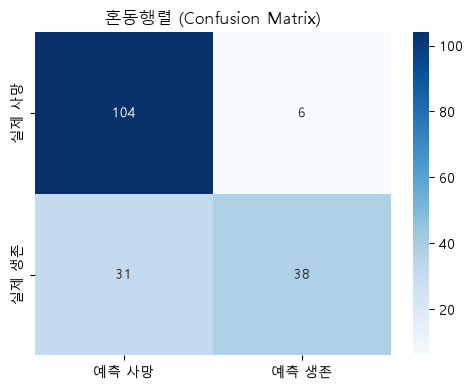

In [37]:
# 혼동행렬 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["예측 사망", "예측 생존"],
            yticklabels=["실제 사망", "실제 생존"])
plt.title("혼동행렬 (Confusion Matrix)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()
